In [1]:
!pip install ml4eft
!pip install wget
!lhapdf install NNPDF31_lo_as_0118

import wget
import tarfile
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

import numpy as np
np.float = float  # patch for deprecated usage

import ml4eft.core.classifier as classifier
import ml4eft.analyse.analyse as analyse
from ml4eft.analyse.animate import Animate
import ml4eft.plotting.features as features
import ml4eft.preproc.constants as constants
mt = constants.mt

rc('text', usetex=False)
rc('font', **{'family': 'DejaVu Sans', 'size': 22})

def file_downloader(url, download_dir='./downloads'):
    if not os.path.exists(download_dir):
        os.mkdir(download_dir)
    file = wget.download(url, out=download_dir)
    return file

def untar(path_to_tar, destination='./downloads'):
    with tarfile.open(path_to_tar) as f:
        f.extractall(destination)

download_dir = './downloads'

PDF already installed: NNPDF31_lo_as_0118 (use --upgrade to force install)
LHAPDF 6.5.4 loading /depot/cms/purdue-af/lhapdf/share/LHAPDF/NNPDF31_lo_as_0118/NNPDF31_lo_as_0118_0000.dat
NNPDF31_lo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 315000


In [2]:
training_data_url = 'https://dl.dropboxusercontent.com/s/z16fz2ggbn244pl/training_data.tar.gz?dl=0'
training_data = file_downloader(training_data_url);
data_train_loc = training_data.split('.tar')[0]

untar(training_data);

# Load in the EFT Events

coeff = ['ctGRe', 'ctj8']
events_eft = []

for c in coeff:
    path_to_events = os.path.join(data_train_loc, 'tt_{}_{}/events_0.pkl.gz'.format(c, c))
    events, xsec = analyse.Analyse.load_events(path_to_events)
    events_eft.append(events)

# Load in the SM events

events_sm, xsec_sm = analyse.Analyse.load_events(os.path.join(download_dir, 'training_data/tt_sm/events_0.pkl.gz'))

obs_features = list(events_sm.columns.values)[1:]

events_sm

,sqrts_hat,pt_l1,pt_l2,pt_l_leading,pt_l_trailing,eta_l1,eta_l2,eta_l_leading,eta_l_trailing,pt_ll,m_ll,DeltaPhi_ll,DeltaEta_ll,pt_b_leading,pt_b_trailing,eta_b_leading,eta_b_trailing,pt_bb,m_bb
1,1702.356400,20.532279,308.295118,308.295118,20.532279,-2.065020,-1.378378,-1.378378,-2.065020,288.661066,167.050330,2.854611,0.686642,719.441642,61.252983,-0.595103,-0.297553,674.939606,397.329956
2,1597.155835,321.296675,93.732180,321.296675,93.732180,2.395675,-0.667281,2.395675,-0.667281,243.808973,835.572285,2.631851,1.728394,228.819181,36.771409,0.064635,2.310805,202.872663,304.906431
3,1860.212511,42.634066,40.346863,42.634066,40.346863,-1.342324,1.666454,-1.342324,1.666454,61.587173,185.989824,1.469631,-0.324129,236.676532,178.887249,-2.127759,1.122896,61.457333,1085.595391
4,1671.151358,44.365954,68.175665,68.175665,44.365954,-1.760597,1.686737,1.686737,-1.760597,51.301018,314.810493,2.289832,0.073860,219.833441,136.899478,1.415762,-1.433425,91.365016,761.785714
5,1467.940000,148.790522,386.021918,386.021918,148.790522,0.689735,-0.993332,-0.993332,0.689735,238.946708,658.674901,3.022271,-0.303597,92.528392,78.369846,-0.388545,0.147944,39.214238,172.644465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,1569.717169,105.491453,215.354621,215.354621,105.491453,1.638092,-0.392135,-0.392135,1.638092,114.986825,469.344045,2.915923,1.245957,160.908767,50.601298,0.043227,0.524358,117.914163,180.981245
99997,1644.498574,38.643304,204.035995,204.035995,38.643304,0.507470,-1.391929,-1.391929,0.507470,185.001844,250.524232,2.170360,-0.884459,260.745097,143.029550,1.227220,-1.177890,179.188087,687.684884
99998,2045.033022,152.320608,177.281070,177.281070,152.320608,-0.246921,0.587674,0.587674,-0.246921,119.945338,337.901110,2.411552,-0.340753,360.362755,145.677331,-0.768837,0.257552,289.274374,482.420600
99999,1763.820943,105.010343,424.436796,424.436796,105.010343,1.104649,-0.186152,-0.186152,1.104649,436.408355,418.359318,1.578891,0.918498,380.500925,302.336989,0.654496,-0.008499,682.650395,229.570577


In [3]:
feature_dict = {
            'pt_l1': r'$p_T^{\ell}\;[\mathrm{GeV}]$',
            'pt_l2': r'$p_T^{\bar{\ell}}\;[\mathrm{GeV}]$',
            'pt_l_leading': r'$p_T^{\ell}\;(\mathrm{leading})\;[\mathrm{GeV}]$',
            'pt_l_trailing': r'$p_T^{\ell}\;(\mathrm{trailing})\;[\mathrm{GeV}]$',
            'eta_l1': r'$\eta_\ell$',
            'eta_l2': r'$\eta_{\bar{\ell}}$',
            'eta_l_leading': r'$\eta_\ell\;(\mathrm{leading})$',
            'eta_l_trailing': r'$\eta_\ell\;(\mathrm{trailing})$',
            'pt_ll': r'$p_T^{\ell\bar{\ell}}\;[\mathrm{GeV}]$',
            'm_ll': r'$m_{\ell\bar{\ell}}\;[\mathrm{GeV}]$',
            'DeltaPhi_ll': r'$\Delta\phi(\ell, \bar{\ell})$',
            'DeltaEta_ll': r'$\Delta\eta(\ell, \bar{\ell})$',
            'pt_b_leading': r'$p_T^{b}\;(\mathrm{leading})\;[\mathrm{GeV}]$',
            'pt_b_trailing': r'$p_T^{b}\;(\mathrm{trailing})\;[\mathrm{GeV}]$',
            'eta_b_leading': r'$\eta_{b}\;(\mathrm{leading})$',
            'eta_b_trailing': r'$\eta_{b}\;(\mathrm{trailing})$',
            'pt_bb': r'$p_T^{b\bar{b}}\;[\mathrm{GeV}]$',
            'm_bb': r'$m_{b\bar{b}}\;[\mathrm{GeV}]$'
}

legend_labels = [r'$c_{tG}=10$', r'$c_{qt}^{(8)}=10$', r'$\mathrm{SM}$']

In [4]:
import json 

path_to_runcard = 'https://dl.dropboxusercontent.com/s/v4ulo6icveh63fw/run_card_tt_llvlvlbb.json?dl=0'
runcard = file_downloader(path_to_runcard)

with open(runcard) as json_runcard:
    json_runcard_loaded = json.load(json_runcard)

json_runcard_loaded['epochs'] = 200
json_runcard_loaded['lr'] = 0.001
json_runcard_loaded['n_batches'] = 50
json_runcard_loaded['patience'] = 20

json_runcard_loaded

with open(runcard, 'w') as runcard_updated:
    json.dump(json_runcard_loaded, runcard_updated)

output_dir = './models'
c_name = 'ctGRe'

In [ ]:
fitter = classifier.Fitter(json_path = runcard,
                           mc_run = 0,
                           c_name = c_name,
                           output_dir = output_dir,
                           print_log = True)

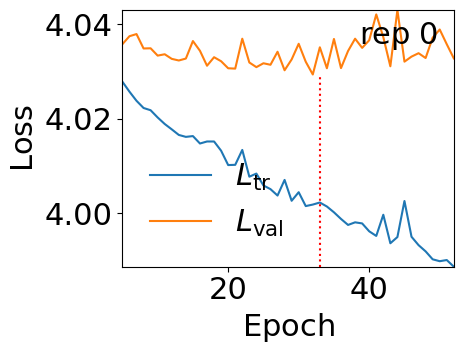

In [5]:
path_to_models_root = os.path.join('./models', time.strftime("2026/02/09"))
order = 'lin'

models_paths_dict = analyse.Analyse.build_path_dict(root=path_to_models_root,
                        order=order,
                        prefix='model')

analyser = analyse.Analyse(models_paths_dict, order, all=True)

fig, _ = analyser.plot_loss_overview(c_name, order, xlim=5)

In [6]:
c_dict = {'ctGRe': 2, 'ctu8': 0}
r_nn = analyser.likelihood_ratio_nn(c=c_dict, df=events_sm).flatten()
r_nn

array([ 0.16431326,  0.45021588,  0.5273895 , ...,  0.06052881,
        0.37511885, -0.464177  ], dtype=float32)

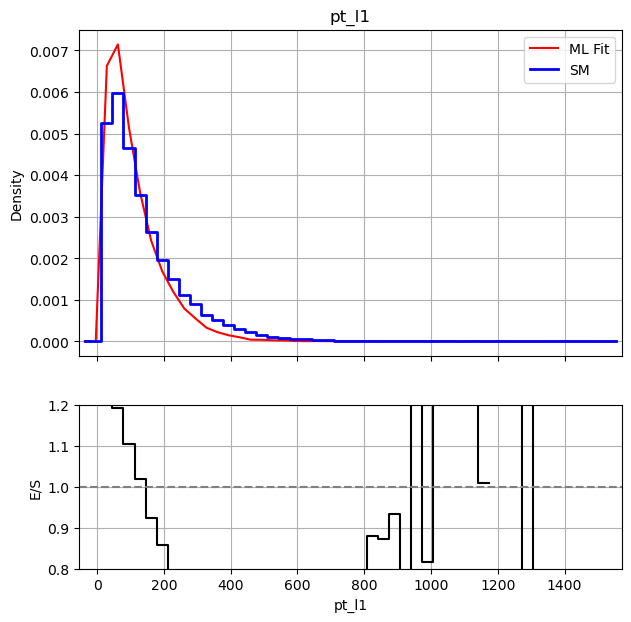

<Figure size 200x200 with 0 Axes>

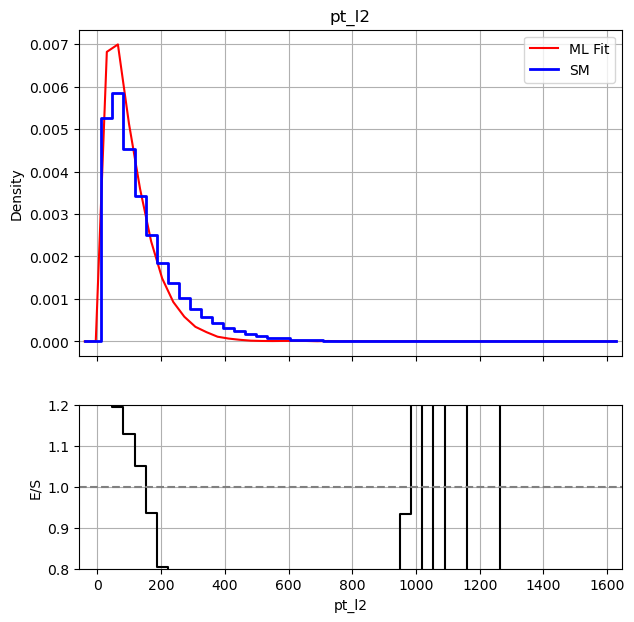

<Figure size 200x200 with 0 Axes>

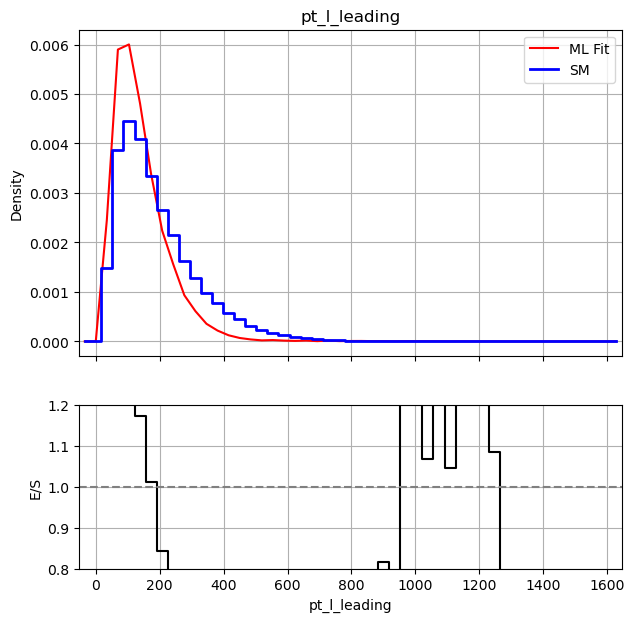

<Figure size 200x200 with 0 Axes>

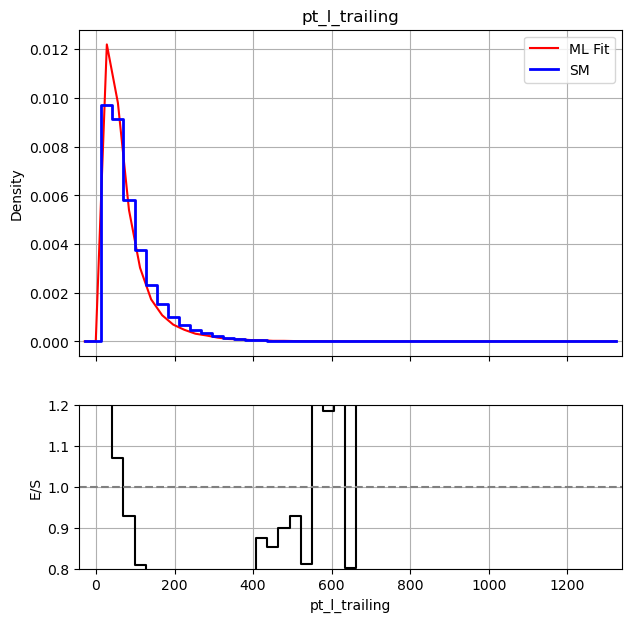

<Figure size 200x200 with 0 Axes>

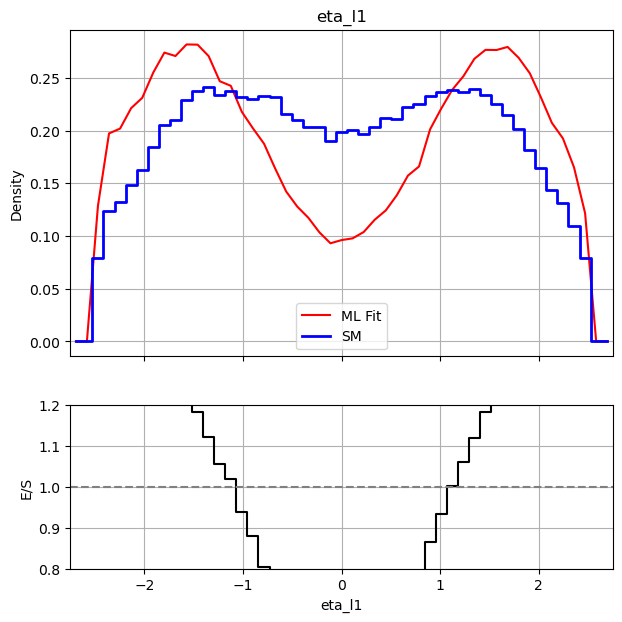

<Figure size 200x200 with 0 Axes>

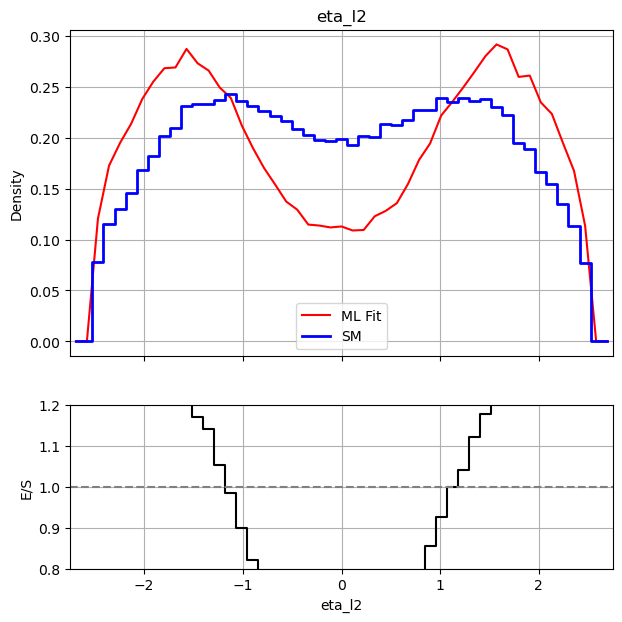

<Figure size 200x200 with 0 Axes>

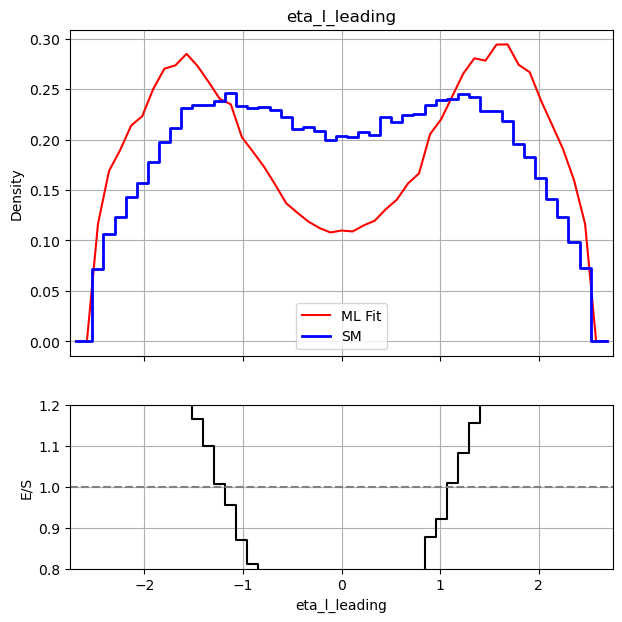

<Figure size 200x200 with 0 Axes>

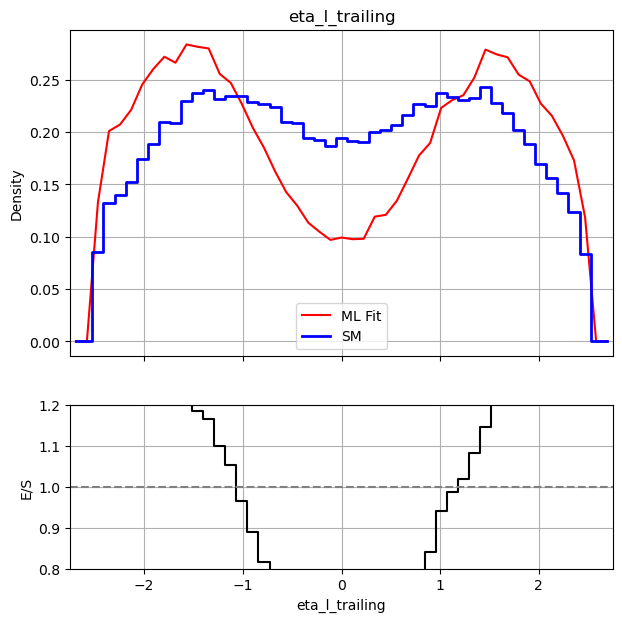

<Figure size 200x200 with 0 Axes>

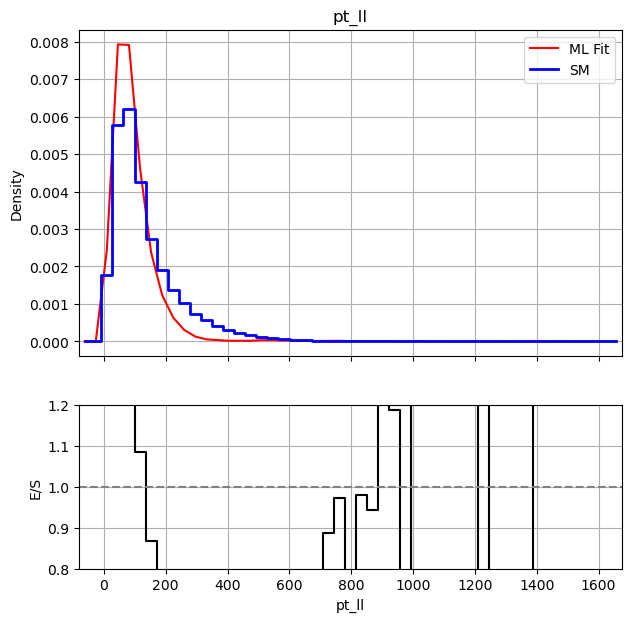

<Figure size 200x200 with 0 Axes>

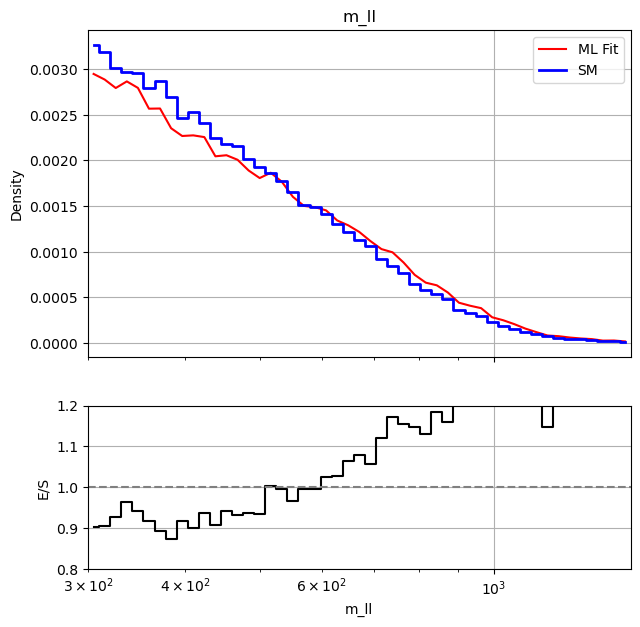

<Figure size 200x200 with 0 Axes>

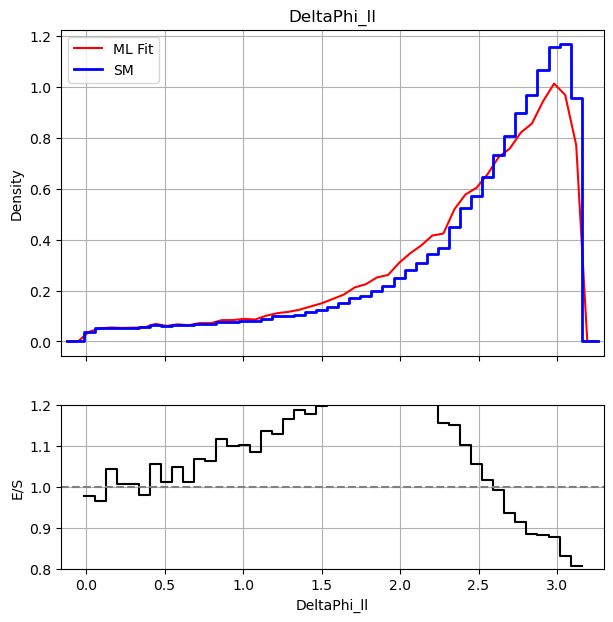

<Figure size 200x200 with 0 Axes>

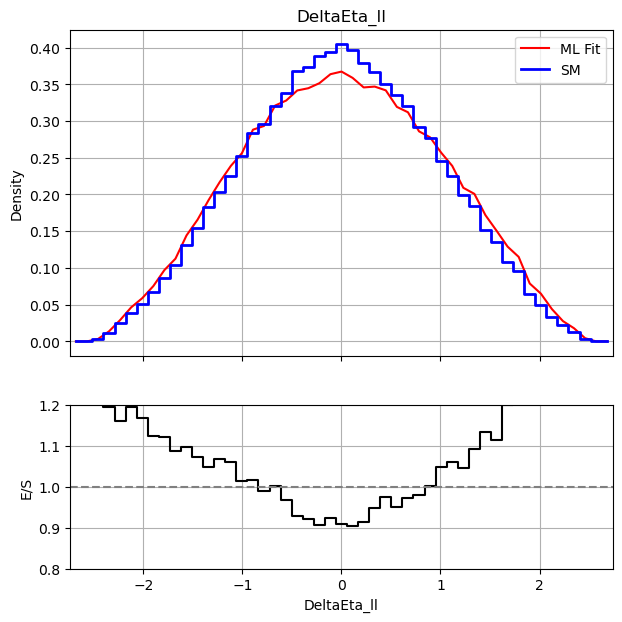

<Figure size 200x200 with 0 Axes>

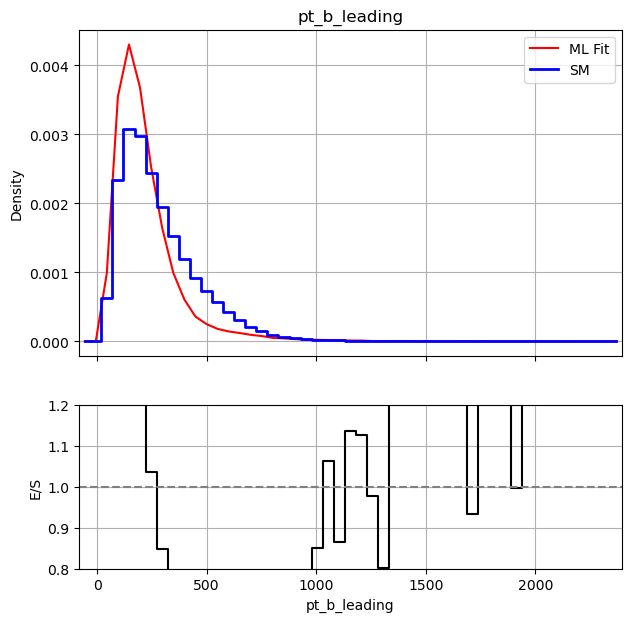

<Figure size 200x200 with 0 Axes>

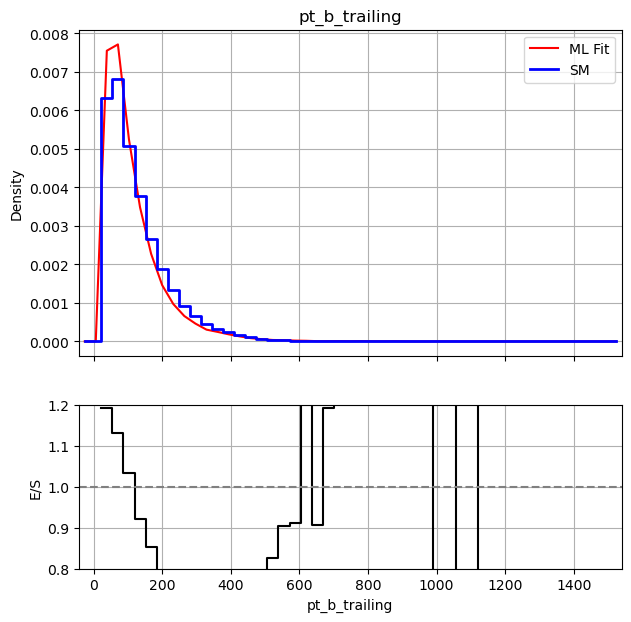

<Figure size 200x200 with 0 Axes>

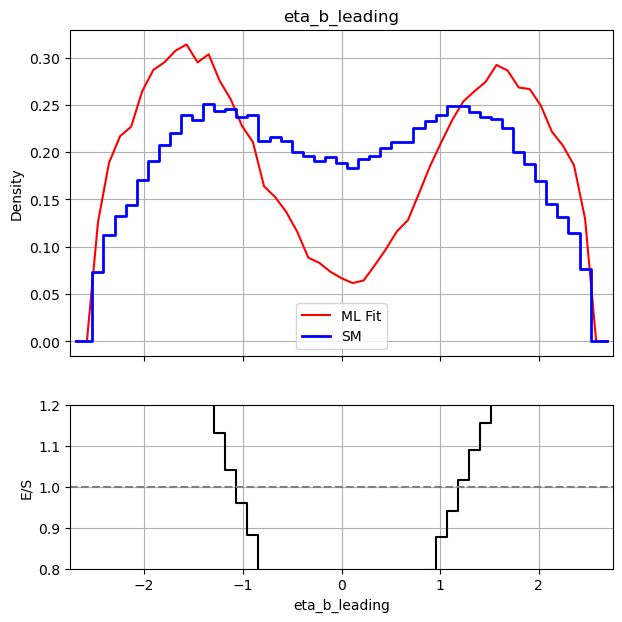

<Figure size 200x200 with 0 Axes>

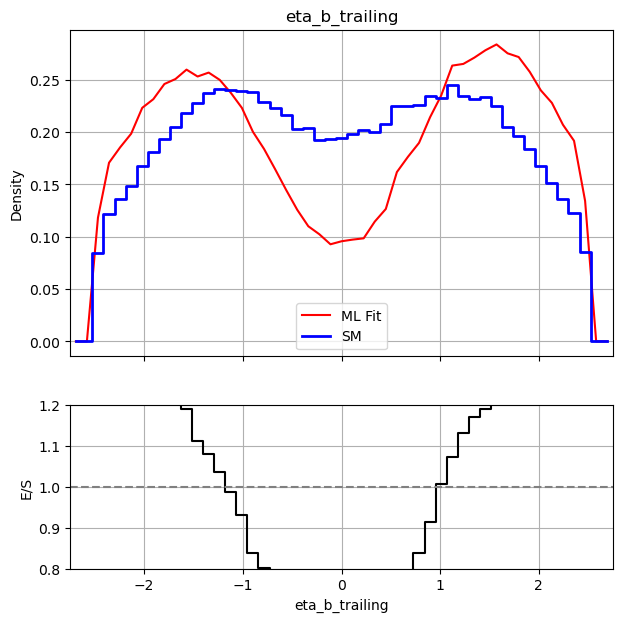

<Figure size 200x200 with 0 Axes>

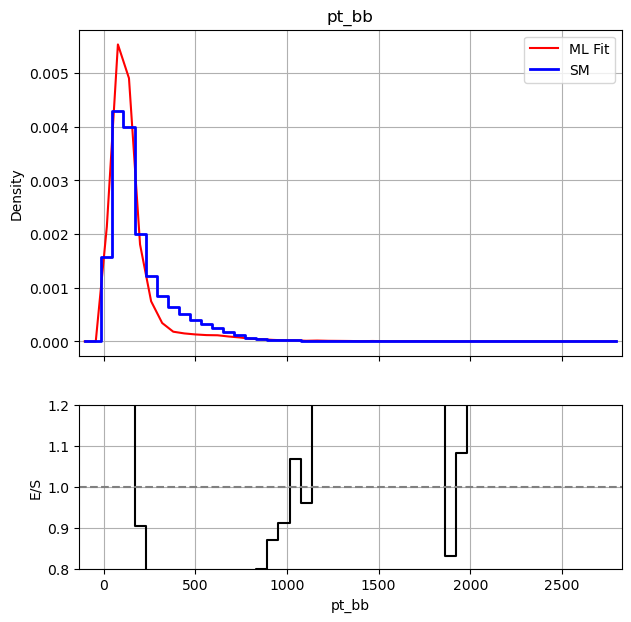

<Figure size 200x200 with 0 Axes>

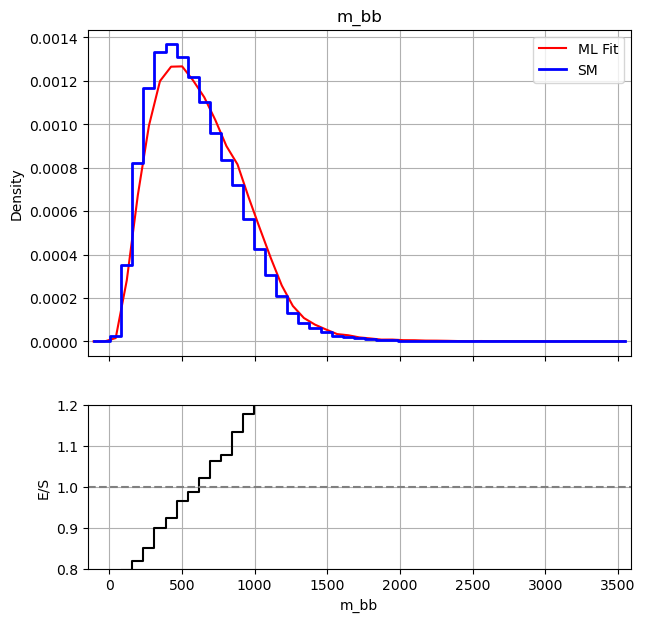

<Figure size 200x200 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 10})


VARS = obs_features

for var in VARS:
    sm_vals = events_sm[var]
    c_dict = {'ctGRe': 2, 'ctu8': 0}
    r_nn = analyser.likelihood_ratio_nn(c=c_dict, df=events_sm).flatten()
    
    if var == "m_ll":
        x_min, x_max = 300, 1500
        bins = np.logspace(np.log10(x_min), np.log10(x_max), 50)
    else:
        buffer = 0.05 * (max(sm_vals) - min(sm_vals))
        x_min = min(sm_vals) - buffer
        x_max = max(sm_vals) + buffer
        bins = np.linspace(x_min, x_max, 50)
    
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    hist_sm, _ = np.histogram(sm_vals, bins=bins, density=True)
    hist_r, _ = np.histogram(sm_vals, bins=bins, weights=r_nn, density=True)
    
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(hist_sm > 0, hist_r / hist_sm, np.nan)
        
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    
    ax_main.plot(bin_centers, hist_r, color='red', lw=1.5, label='ML Fit')
    ax_main.step(bin_centers, hist_sm, where='mid', label="SM", color='blue', linewidth=2)
    ax_main.set_ylabel("Density")
    ax_main.set_title(var)
    ax_main.legend()
    ax_main.grid(True)
    
    ax_main.set_xlim(x_min, x_max)

    if var == "m_ll":
        ax_main.set_xscale("log")
        ax_main.set_xlim(300, 1500)
    else:
        ax_main.set_xlim(x_min, x_max)
        
    # Ratio plot
    ax_ratio.step(bin_centers, ratio, where='mid', color='black')
    ax_ratio.axhline(1.0, linestyle="--", color="gray")
    ax_ratio.set_ylabel("E/S")
    ax_ratio.set_xlabel(var)
    ax_ratio.set_ylim(0.8, 1.2)
    ax_ratio.grid(True)
    ax_ratio.set_xlim(x_min, x_max)

    if var == "m_ll":
        ax_ratio.set_xscale("log")
        ax_ratio.set_xlim(300, 1500)
    else:
        ax_ratio.set_xlim(x_min, x_max)
    plt.figure(figsize=(2, 2))
    plt.subplots_adjust(hspace=0.1)
    plt.tight_layout()
    plt.show()
